In [0]:
import warnings
warnings.filterwarnings('ignore')

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

import shap

from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [0]:
pd.set_option('display.max_colwidth', None)

In [0]:
COLUNA_ALVO = 'Class'
RANDOM_STATE = 42

In [0]:
df = pd.read_csv('./creditcard.csv', delimiter=',')
print("Shape:", df.shape)
print("Columns:", df.columns)

X_full = df.drop(COLUNA_ALVO, axis=1)
y_full = df[COLUNA_ALVO]

Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [0]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

## Grids e modelos

In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), ['Time', 'Amount'])
    ],
    remainder='passthrough'
)

In [0]:
pipeline_lr_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        solver='liblinear', 
        max_iter=500
    ))
])

param_grid_lr_weighted = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1],
    'model__solver': ['liblinear', 'saga']
}


pipeline_rfc_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'
    ))
])

param_grid_rfc_weighted = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [10, None],
    'model__min_samples_leaf': [1, 5]
}


pipeline_knn_distance = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(weights='distance', n_jobs=-1))
])

param_grid_knn = {
    'model__n_neighbors': [3, 5]
}

pos_count = int(y_train.sum())
neg_count = int((y_train == 0).sum())
scale_pos_weight = neg_count / max(1, pos_count)

pipeline_xgb_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])

param_grid_xgb_weighted = {
    "model__max_depth": [10, 50],
    "model__learning_rate": [0.1, 0.01],
    "model__n_estimators": [30, 500]
}

In [0]:
models_to_run= {
    'rfc_weight': {
        'estimator': pipeline_rfc_weighted,
        'param_grid': param_grid_rfc_weighted
    },
    'lr_weight': {
        'estimator': pipeline_lr_weighted,
        'param_grid': param_grid_lr_weighted
    },
    'XGBoost_Weighted': {
        'estimator': pipeline_xgb_weighted,
        'param_grid': param_grid_xgb_weighted
    },
    'knn': {
        'estimator': pipeline_knn_distance,
        'param_grid': param_grid_knn
    }
}

In [0]:
def run_single_model_nested_cv(
    estimator,
    param_grid,
    X,
    y,
    scoring=['accuracy', 'recall', 'precision', 'f1', 'roc_auc'],
    n_splits_outer=3,
    n_splits_inner=3,
    scoring_grid_search='f1',
    random_state=RANDOM_STATE):
    
    cv_inner = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=random_state)
    cv_outer = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=random_state)

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring_grid_search,
        cv=cv_inner,
        refit=True,
        n_jobs=1
    )

    output_ncv = cross_validate(
        estimator=search,
        X=X,
        y=y,
        scoring=scoring,
        cv=cv_outer,
        n_jobs=-1,
        return_estimator=True,
        return_train_score=True
    )

    df_results = pd.DataFrame(output_ncv)

    metrics_cols = [col for col in df_results.columns if col.startswith('test_')]
    summary = df_results[metrics_cols].agg(['mean', 'std']).round(3)

    return df_results, summary
    

In [0]:
all_results = []
all_summaries = []

for model_name, config in models_to_run.items():
    print(f"Rodando modelo: {model_name}")
    
    df_model_results, df_model_summary = run_single_model_nested_cv(
        estimator=config['estimator'],
        param_grid=config['param_grid'],
        X=X_train,
        y=y_train
    )
    
    df_model_results['model'] = model_name
    df_model_summary['model'] = model_name

    all_results.append(df_model_results)
    all_summaries.append(df_model_summary)

final_results_df = pd.concat(all_results, ignore_index=True)
final_results_df['best_params'] = final_results_df['estimator'].apply(lambda est: est.best_params_)
final_summary_df = pd.concat(all_summaries, keys=[key for key in models_to_run.keys()])

Rodando modelo: rfc_weight


com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:190)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:201)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
final_results_df.sort_values(['model', 'test_f1'], ascending=False)

,fit_time,score_time,estimator,test_accuracy,train_accuracy,test_recall,train_recall,test_precision,train_precision,test_f1,train_f1,test_roc_auc,train_roc_auc,model,best_params
2,322.088812,0.147430,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n RandomForestClassifier(class_weight='balanced',\n n_jobs=-1,\n random_state=42))]),\n n_jobs=1,\n param_grid={'model__max_depth': [10, None],\n 'model__min_samples_leaf': [1, 5],\n 'model__n_estimators': [100, 300]},\n scoring='f1')",0.999526,1.000000,0.786260,1.000000,0.927928,1.000000,0.851240,1.000000,0.956610,1.000000,rfc_weight,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}"
0,321.834774,0.146973,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n RandomForestClassifier(class_weight='balanced',\n n_jobs=-1,\n random_state=42))]),\n n_jobs=1,\n param_grid={'model__max_depth': [10, None],\n 'model__min_samples_leaf': [1, 5],\n 'model__n_estimators': [100, 300]},\n scoring='f1')",0.999473,0.999849,0.772727,1.000000,0.910714,0.919298,0.836066,0.957952,0.969696,0.999972,rfc_weight,"{'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}"
1,318.893699,1.479963,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n RandomForestClassifier(class_weight='balanced',\n n_jobs=-1,\n random_state=42))]),\n n_jobs=1,\n param_grid={'model__max_depth': [10, None],\n 'model__min_samples_leaf': [1, 5],\n 'model__n_estimators': [100, 300]},\n scoring='f1')",0.999355,0.999842,0.709924,0.992395,0.894231,0.922261,0.791489,0.956044,0.960736,0.999962,rfc_weight,"{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}"
4,467.567921,0.055786,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n LogisticRegression(class_weight='balanced',\n max_iter=500,\n random_state=42,\n solver='liblinear'))]),\n n_jobs=1,\n param_grid={'model__C': [0.01, 0.1],\n 'model__penalty': ['l1', 'l2'],\n 'model__solver': ['liblinear', 'saga']},\n scoring='f1')",0.978156,0.978308,0.893130,0.939163,0.066402,0.070051,0.123613,0.130377,0.968559,0.991654,lr_weight,"{'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}"
3,434.316029,0.057091,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n LogisticRegression(class_weight='balanced',\n max_iter=500,\n random_state=42,\n solver='liblinear'))]),\n n_jobs=1,\n param_grid={'model__C': [0.01, 0.1],\n 'model__penalty': ['l1', 'l2'],\n 'model__solver': ['liblinear', 'saga']},\n scoring='f1')",0.975141,0.974713,0.916667,0.919847,0.060561,0.059345,0.113615,0.111497,0.982306,0.989322,lr_weight,"{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}"
5,460.680127,0.056014,"GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),\n estimator=Pipeline(steps=[('preprocessor',\n ColumnTransformer(remainder='passthrough',\n transformers=[('scaler',\n StandardScaler(),\n ['Time',\n 'Amount'])])),\n ('model',\n LogisticRegression(class_weight='balance

In [0]:
final_summary_df

test_accuracy  ...             model
rfc_weight       mean          0.999  ...        rfc_weight
                 std           0.000  ...        rfc_weight
lr_weight        mean          0.976  ...         lr_weight
                 std           0.002  ...         lr_weight
XGBoost_Weighted mean          1.000  ...  XGBoost_Weighted
                 std           0.000  ...  XGBoost_Weighted
knn              mean          0.999  ...               knn
                 std           0.000  ...               knn

[8 rows x 6 columns]

=== Métricas de desempenho ===
F1 Score:     0.1155
Precisão:     0.0616
Recall:       0.9184
ROC AUC:      0.9725


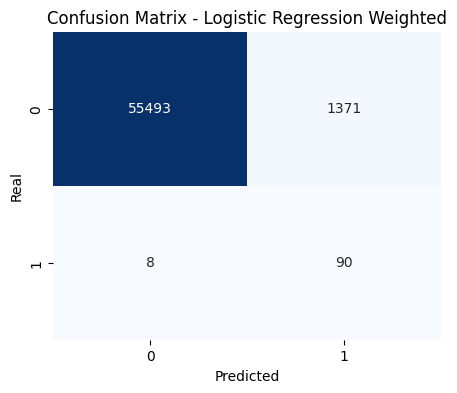

In [0]:
param_grid_lr_weighted = {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

pipeline_lr_weighted.set_params(**param_grid_lr_weighted)
pipeline_lr_weighted.fit(X_train, y_train)

y_pred = pipeline_lr_weighted.predict(X_test)
y_proba = pipeline_lr_weighted.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Logistic Regression Weighted")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.8391
Precisão:     0.9605
Recall:       0.7449
ROC AUC:      0.9530


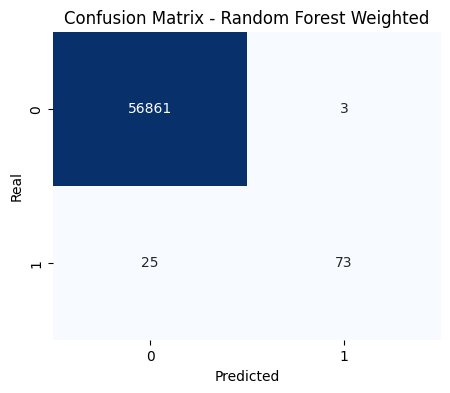

In [0]:
param_grid_rfc_weighted = {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

pipeline_rfc_weighted.set_params(**param_grid_rfc_weighted)
pipeline_rfc_weighted.fit(X_train, y_train)

y_pred = pipeline_rfc_weighted.predict(X_test)
y_proba = pipeline_rfc_weighted.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Random Forest Weighted")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.8757
Precisão:     0.9310
Recall:       0.8265
ROC AUC:      0.9285


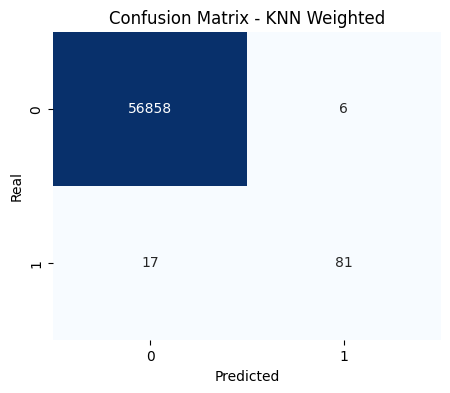

In [0]:
param_grid_knn_weighted = {'model__n_neighbors': 3}

pipeline_knn_distance.set_params(**param_grid_knn_weighted)
pipeline_knn_distance.fit(X_train, y_train)

y_pred = pipeline_knn_distance.predict(X_test)
y_proba = pipeline_knn_distance.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - KNN Weighted")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

=== Métricas de desempenho ===
F1 Score:     0.8571
Precisão:     0.8901
Recall:       0.8265
ROC AUC:      0.9736


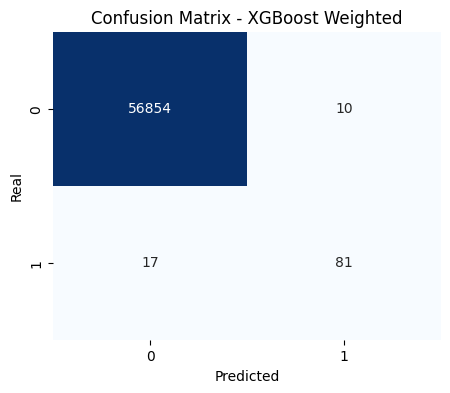

In [0]:
param_grid_xgb_weighted = {'model__learning_rate': 0.1, 'model__max_depth': 50, 'model__n_estimators': 500}

pipeline_xgb_weighted.set_params(**param_grid_xgb_weighted)
pipeline_xgb_weighted.fit(X_train, y_train)

y_pred = pipeline_xgb_weighted.predict(X_test)
y_proba = pipeline_xgb_weighted.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== Métricas de desempenho ===")
print(f"F1 Score:     {f1:.4f}")
print(f"Precisão:     {precision:.4f}")
print(f"Recall:       {recall:.4f}")
print(f"ROC AUC:      {roc_auc:.4f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - XGBoost Weighted")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.show()

In [ ]:
X_test_trans = pipeline_xgb_weighted[:-1].transform(X_test)
def clean_feature_names(feature_names):
    cleaned = []
    for f in feature_names:
        if "__" in f:
            cleaned.append(f.split("__", 1)[1])   # remove "remainder__"
        else:
            cleaned.append(f)
    return np.array(cleaned)

preproc = pipeline_xgb_weighted.named_steps["preprocessor"]
try:
    raw_feature_names = preproc.get_feature_names_out()
    feature_names = clean_feature_names(raw_feature_names)
except Exception:
    feature_names = np.array([f"f_{i}" for i in range(X_test_trans.shape[1])])

xgb_model = pipeline_xgb_weighted.named_steps["model"]
dtest = xgb.DMatrix(X_test_trans)

# 3) SHAP contributions diretamente do XGBoost
contribs = xgb_model.get_booster().predict(dtest, pred_contribs=True, approx_contribs=False)

shap_vals = contribs[:, :-1]                 # (n_samples, n_features)
base_vals = contribs[:, -1]                  # (n_samples,)

shap_exp = shap.Explanation(
    values=shap_vals,
    base_values=base_vals,
    data=X_test_trans,
    feature_names=feature_names
)

# 5) Plots globais
plt.figure()
shap.plots.bar(shap_exp, max_display=20, show=False)
plt.title("SHAP Feature Importance - XGBoost (pred_contribs)")
plt.tight_layout(); plt.show()

plt.figure()
shap.plots.beeswarm(shap_exp, max_display=25, show=False)
plt.title("SHAP Beeswarm - XGBoost (pred_contribs)")
plt.tight_layout(); plt.show()